In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import ipywidgets as widgets

# Enable inline plotting in Google Colab
%matplotlib inline

In [11]:
df = pd.read_csv('Cleaned Amazon Sale Report.csv')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128942 entries, 0 to 128941
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Order ID            128942 non-null  object 
 1   Date                128942 non-null  object 
 2   Status              128942 non-null  object 
 3   Fulfilment          128942 non-null  object 
 4   Sales Channel       128942 non-null  object 
 5   ship-service-level  128942 non-null  object 
 6   Style               128942 non-null  object 
 7   SKU                 128942 non-null  object 
 8   Category            128942 non-null  object 
 9   Size                128942 non-null  object 
 10  ASIN                128942 non-null  object 
 11  Courier Status      128942 non-null  object 
 12  Qty                 128942 non-null  int64  
 13  Amount              128942 non-null  float64
 14  ship-city           128942 non-null  object 
 15  ship-state          128942 non-nul

In [14]:
# Set Date column format
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True)

In [15]:
# Setting correct data types
df = df.convert_dtypes()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128942 entries, 0 to 128941
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128942 non-null  string        
 1   Date                128942 non-null  datetime64[ns]
 2   Status              128942 non-null  string        
 3   Fulfilment          128942 non-null  string        
 4   Sales Channel       128942 non-null  string        
 5   ship-service-level  128942 non-null  string        
 6   Style               128942 non-null  string        
 7   SKU                 128942 non-null  string        
 8   Category            128942 non-null  string        
 9   Size                128942 non-null  string        
 10  ASIN                128942 non-null  string        
 11  Courier Status      128942 non-null  string        
 12  Qty                 128942 non-null  Int64         
 13  Amount              128942 no

In [26]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Cancelled,0,647.62,MUMBAI,MAHARASHTRA,400081,IN,False
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.0,BENGALURU,KARNATAKA,560085,IN,False
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.0,NAVI MUMBAI,MAHARASHTRA,410210,IN,True
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Cancelled,0,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.0,CHENNAI,TAMIL NADU,600073,IN,False


## Google Looker Studio

[Dashboard](https://lookerstudio.google.com/reporting/106f6e80-867e-42bb-a002-1008beb855a6)

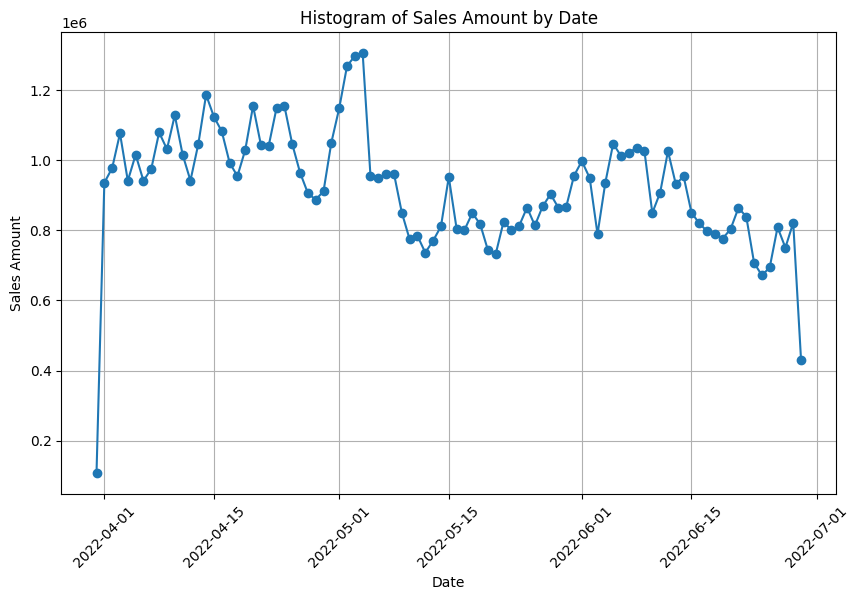

In [20]:
sales = df.groupby('Date').sum()
plt.figure(figsize=(10, 6))
plt.plot(sales.index, sales['Amount'], marker='o')
plt.title('Histogram of Sales Amount by Date')
plt.xlabel('Date')
plt.ylabel('Sales Amount')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

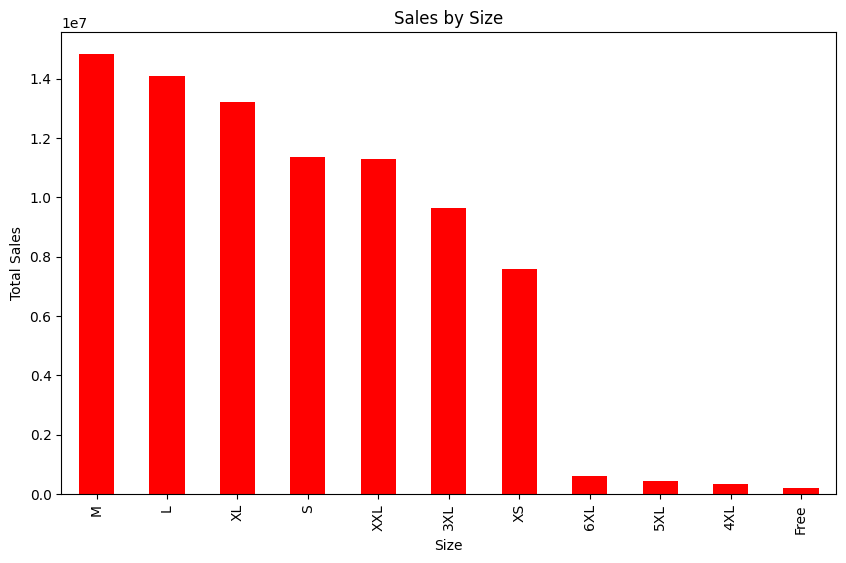

In [21]:
sales_by_size = df.groupby('Size')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sales_by_size.plot(kind='bar', color='red')
plt.title('Sales by Size')
plt.xlabel('Size')
plt.ylabel('Total Sales')
plt.show()

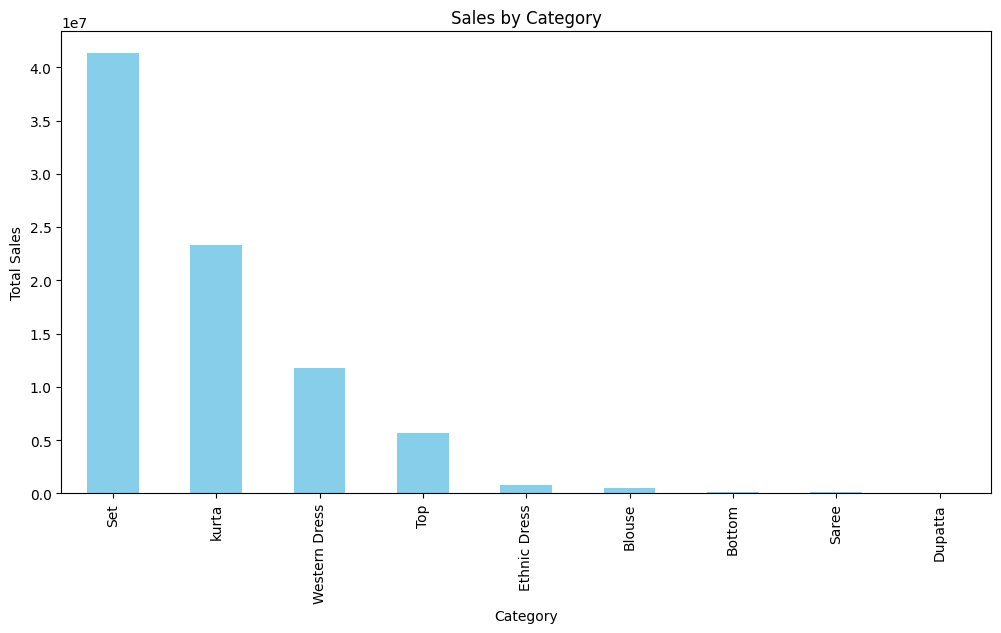

In [22]:
sales_by_category = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sales_by_category.plot(kind='bar', color='skyblue')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.show()

In [25]:
df['Status'].value_counts()

,count
Status,
Shipped,77788
Shipped - Delivered to Buyer,28762
Cancelled,18325
Shipped - Returned to Seller,1950
Shipped - Picked Up,973
Pending,658
Pending - Waiting for Pick Up,281
Shipped - Returning to Seller,145
Shipped - Out for Delivery,35


In [37]:
df['Size'].astype('category').cat.codes

,0
0,7
1,0
2,8
3,5
4,0
...,...
128937,8
128938,6
128939,10
128940,9


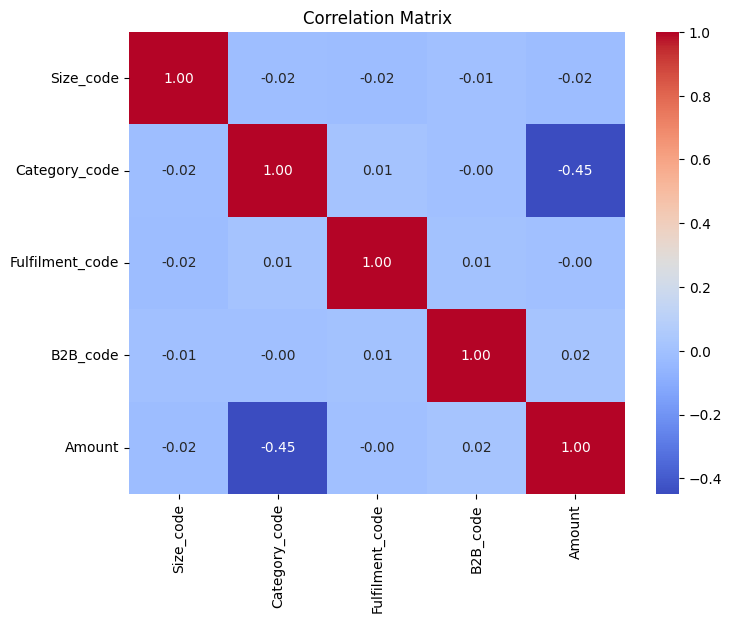

In [38]:
# Convert categorical columns 'Size', 'Category', 'Status' to numeric codes
df['Size_code'] = df['Size'].astype('category').cat.codes
df['Category_code'] = df['Category'].astype('category').cat.codes
df['Fulfilment_code'] = df['Fulfilment'].astype('category').cat.codes
df['B2B_code'] = df['B2B'].astype('category').cat.codes

# Create a correlation matrix for relevant numeric columns
correlation_matrix = df[['Size_code', 'Category_code', 'Fulfilment_code', 'B2B_code', 'Amount']].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()